# Script 6 - Constrained Ordination hello

# Librairies

In [1]:
library(vegan)

Loading required package: permute



# Loading data and removing empty site 8

<div style="padding: 10px; border:1px solid green; font-size: 10px;">
  <span style="font-size: 15px;"> <i>Loading the data from Doubs</i> </span><br/>
</div>

In [2]:
# Load the Doubs data
load("Doubs.RData")
# Remove empty site 8
spe <- spe[-8, ]
env <- env[-8, ]
spa <- spa[-8, ]

# Loading modified Doubs data 

<div style="padding: 10px; border:1px solid green; font-size: 10px;">
  <span style="font-size: 15px;"> <i>Loading the data from Doubs with a <strong>modified</strong> <strong><code>env</code></strong> dataset using qualitative slope factor (<strong><code>env3</code></strong>) and 2 subsets of explanatory variables (<strong><code>envchem</code></strong>,<strong><code>envtopo</code></strong>)</i> </span><br/>
</div>

In [3]:
# Load the Modified Doubs data
load("DoubsModified.Rdata")

# 1 Detrended Correspondence Analysis (DCA) -> *rda(),decorana()*

<div style="padding: 10px; border:5px solid green; font-size: 10px; text-align: center;">
    <img src="images/Script6_DCA.png" width="65%" >
</div>

<div style="padding: 10px; border:1px solid red; font-size: 18px; position: relative;">
  <span style="text-decoration:underline; font-weight: bold; font-size: 22px;">Question 1</span><br/>

  <div style="display: flex; align-items: flex-start;">
    <div style="flex: 1;">
        What are the ordinations methods maily affected by the horseshoe/arch effect ? <br/>
    </div>
  </div>

<form>
  <label><input type="radio" name="q5" value="1"> 1) PCA </label><br/>
  <label><input type="radio" name="q5" value="2"> 2) CA</label><br/>
  <label><input type="radio" name="q5" value="2"> 3) NMDS </label><br/>
  <label><input type="radio" name="q5" value="2"> 4) All these methods </label><br/>
</form>

</div>

<details style="font-size: 18px;">
  <summary style="font-size: 20px; font-weight: bold; text-decoration: underline;">Answer</summary>
  <div style="padding: 10px; border:1px solid blue; font-size: 20px;">

<form>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring"> 1) PCA </label><br/>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring"> 2)  CA</label><br/>
  <label><input type="radio" name="q5" value="2"> 3) NMDS </label><br/>
  <label><input type="radio" name="q5" value="2"> 4) All these methods </label><br/>

</form>



  </div>
</details>



### 1.0.1 DCA computation based on a dataframe → ***decorana**( df, iweigh=, iresc=, ira=, mk=, short=, before=, after=)*

*Detrended Correspondence Analysis (DCA) computation based on a dataframe*

- **`df`** → *Dataframe on which the DCA is computed (usually species abundance data)*  
- **`iweigh`** → *Downweighting of rare species.*  
  - `0`: no down-weighting (default)  
  - `1`: down-weight rare species  
- **`iresc`** → *Number of rescaling cycles*  
  - `0`: no rescaling  
- **`ira`** → *Type of analysis*  
  - `0`: detrended  
  - `1`: basic reciprocal averaging  
- **`mk`** → *Number of segments in rescaling.*  
- **`short`** → *Shortest gradient to be rescaled.*  
  - `0`: no shortening (default)  
  - `1`: shortening applied  
- **`before`** → *Hill's piecewise transformation: values before transformation.*  
- **`after`** → *Hill's piecewise transformation: values after transformation -- these must correspond to values in before*

  
**outputs** :
- **`Total inertia (scaled Chi-square)`**:  *The total variance in the dataset measured as the scaled Chi-square statistic*
- **`Eigen Values`**: *Values indicating the amount of variation explained by each PCA axis*
- **`Additive Eigen Values`**: * Values indicating the amount of variation explained by each DCA axis*
- **`Decorana Values`**: *Special scores computed during the detrending process, used to correct the arch effect and improve ecological interpretability.*
- **`Axis Length`**: *Length of each DCA axis expressed in standard deviation units; longer axes indicate stronger species turnover along that gradient.*


## 1.1 Demonstrating DCA over PCA Using the `varespec` Dataset

### 1.1.1 Load and the display the `varespec` Dataset

In [4]:
# Loads the 'varespec' dataset from the vegan package. It contains species abundances from vegetation samples.
data("varespec")  

# Displays the contents of the 'varespec' dataset (a community data table with species as columns and samples as rows).
head(varespec)

,Callvulg,Empenigr,Rhodtome,Vaccmyrt,Vaccviti,Pinusylv,Descflex,Betupube,Vacculig,Diphcomp,⋯,Cetreric,Cetrisla,Flavniva,Nepharct,Stersp,Peltapht,Icmaeric,Cladcerv,Claddefo,Cladphyl
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18,0.55,11.13,0.00,0.00,17.80,0.07,0.00,0,1.60,2.07,⋯,0.02,0.00,0.12,0.02,0.62,0.02,0,0,0.25,0
15,0.67,0.17,0.00,0.35,12.13,0.12,0.00,0,0.00,0.00,⋯,0.15,0.03,0.00,0.00,0.85,0.00,0,0,1.00,0
24,0.10,1.55,0.00,0.00,13.47,0.25,0.00,0,0.00,0.00,⋯,0.78,0.12,0.00,0.00,0.03,0.00,0,0,0.33,0
27,0.00,15.13,2.42,5.92,15.97,0.00,3.70,0,1.12,0.00,⋯,0.00,0.00,0.00,0.00,0.00,0.07,0,0,0.15,0
23,0.00,12.68,0.00,0.00,23.73,0.03,0.00,0,0.00,0.00,⋯,0.00,0.00,0.02,0.00,1.58,0.33,0,0,1.97,0
19,0.00,8.92,0.00,2.42,10.28,0.12,0.02,0,0.00,0.00,⋯,0.00,0.00,0.02,0.00,0.28,0.00,0,0,0.37,0


### 1.1.2 Applies Hellinger transformation to the species data

In [5]:
# Applies Hellinger transformation to the species data.(Reduces the influence of large abundances and zero inflation).
vare.hel <- decostand(varespec, "hellinger")

### 1.1.3 Performs Principal Component Analysis (PCA)

In [6]:
# Performs Principal Component Analysis (PCA) using the `rda` function. `scaling = 1` scales species scores to unit variance.
vare.PCA<-rda(vare.hel,scaling=1)
# Prints a summary of the PCA object
vare.PCA


Call: rda(X = vare.hel, scaling = 1)

              Inertia Rank
Total          0.3647     
Unconstrained  0.3647   23

Inertia is variance

Eigenvalues for unconstrained axes:
    PC1     PC2     PC3     PC4     PC5     PC6     PC7     PC8 
0.14586 0.07908 0.02866 0.02446 0.02209 0.01263 0.01179 0.00873 
(Showing 8 of 23 unconstrained eigenvalues)


### 1.1.4 Plot the PCA

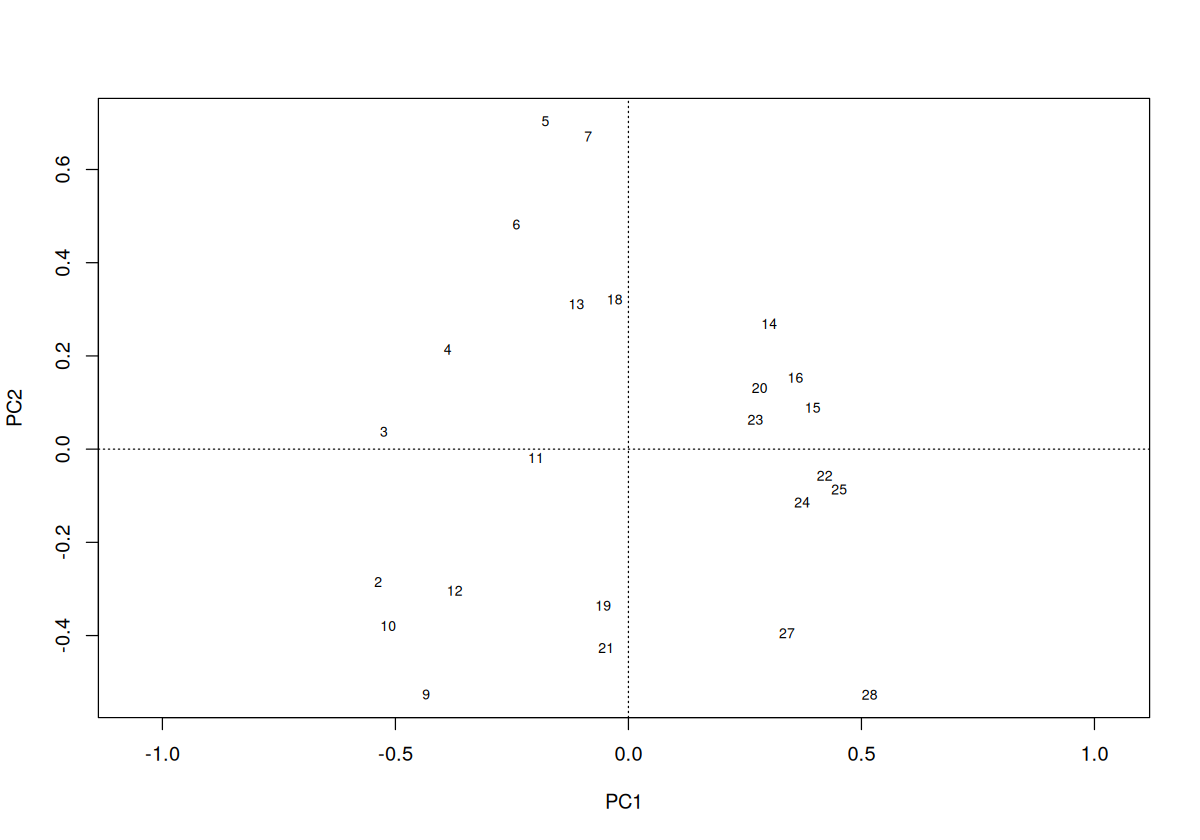

In [7]:
# Set plot size in Jupyter Notebook (10 x 7 inches)
options(repr.plot.width = 10, repr.plot.height = 7)

# Plots the PCA ordination diagram, showing only the sites (samples) in the plot.
plot(vare.PCA, display="sites")

### 1.1.5 Performs and plot Detrended Correspondence Analysis (DCA)


Call:
decorana(veg = varespec, iweigh = 0, iresc = 4, ira = 0, mk = 26,      short = 0, before = NULL, after = NULL) 

Detrended correspondence analysis with 26 segments.
Rescaling of axes with 4 iterations.
Total inertia (scaled Chi-square): 2.0832 

                       DCA1   DCA2    DCA3    DCA4
Eigenvalues          0.5235 0.3253 0.20010 0.19176
Additive Eigenvalues 0.5235 0.3217 0.17919 0.11922
Decorana values      0.5249 0.1572 0.09669 0.06075
Axis lengths         2.8161 2.2054 1.54650 1.64864


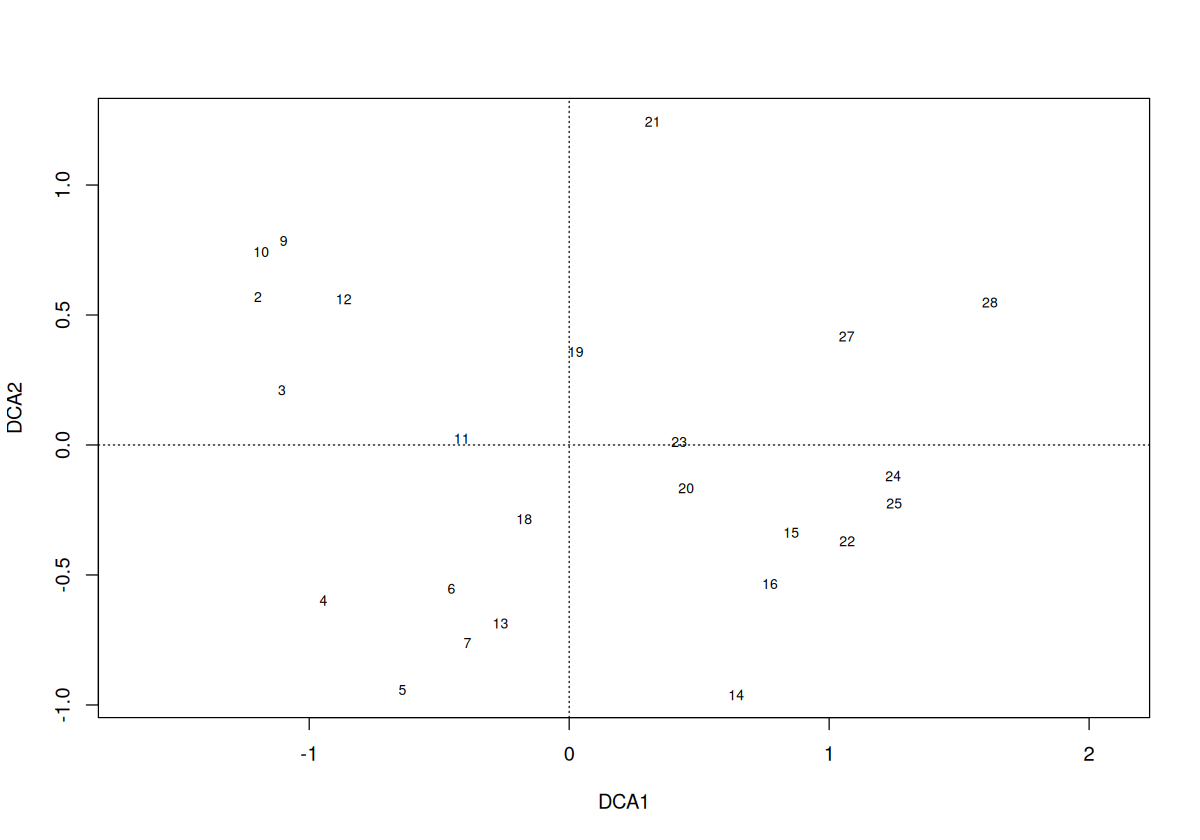

In [8]:
# Performs Detrended Correspondence Analysis (DCA) on the 'varespec' dataset
vare.DCA<-decorana(varespec, iweigh=0, iresc=4, ira=0, mk=26, short=0, before=NULL, after=NULL)
# Display the DCA outputs
vare.DCA
# Set plot size in Jupyter Notebook (10 x 7 inches)
options(repr.plot.width = 10, repr.plot.height = 7)

# Plots the DCA ordination diagram
plot(vare.DCA, disp="sites")

### 1.1.6 Comparison between simple PCA and a DCA

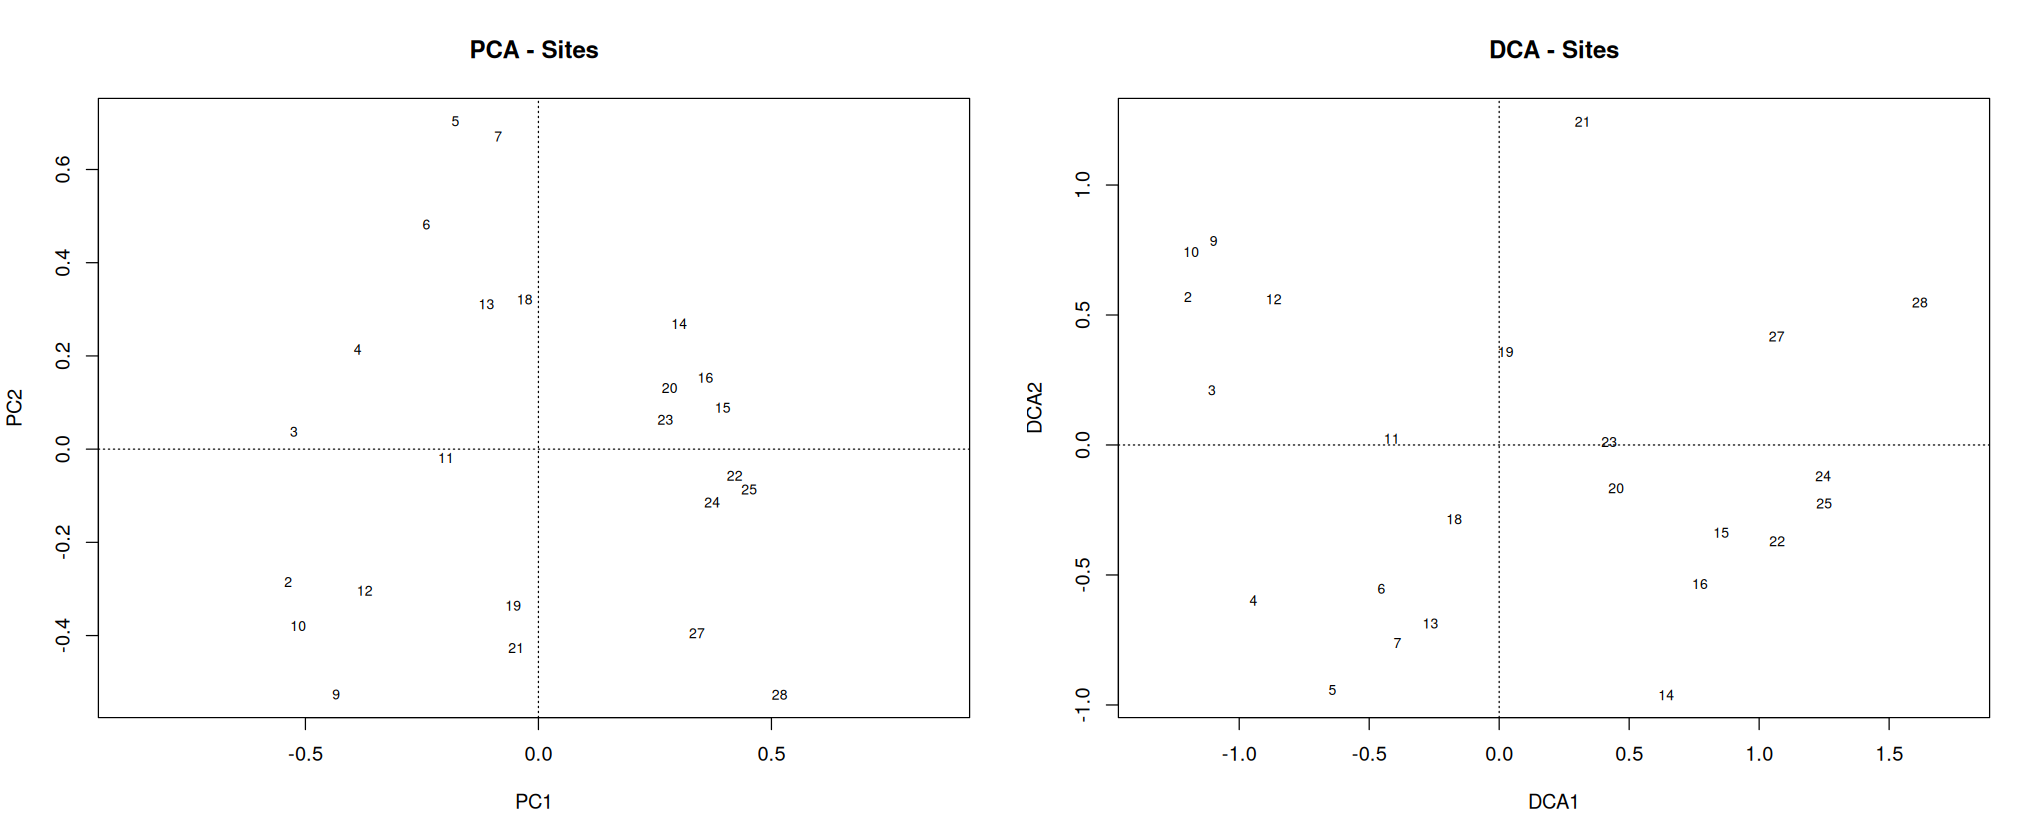

In [9]:
# Set plot size in Jupyter Notebook (17 x 7 inches)
options(repr.plot.width = 17, repr.plot.height = 7)

# Set plot layout to 1 row, 2 columns (side-by-side)
par(mfrow = c(1, 2))

# Plot PCA sites
plot(vare.PCA, display = "sites", main = "PCA - Sites")

# Plot DCA sites
plot(vare.DCA, disp = "sites", main = "DCA - Sites")

# 2 Redundancy analysis (RDA) -> *rda()*

<div style="padding: 10px; border:5px solid green; font-size: 10px; text-align: left;">
    <img src="images/Script6_RDA.png" width="35%" style="margin-right: 90px;">
    <img src="images/Script6_RDA_triplot.png" width="35%">
</div>


<div style="padding: 10px; border:1px solid red; font-size: 18px; position: relative;">
  <span style="text-decoration:underline; font-weight: bold; font-size: 22px;">Question 2</span><br/>

  <div style="display: flex; align-items: flex-start;">
    <div style="flex: 1;">
        To which unconstrained ordination method is the RDA an extension? <br/>
    </div>
  </div>

<form>
  <label><input type="radio" name="q5" value="1"> 1) PCA </label><br/>
  <label><input type="radio" name="q5" value="2"> 2) CA</label><br/>
  <label><input type="radio" name="q5" value="2"> 3) NMDS </label><br/>
  <label><input type="radio" name="q5" value="2"> 4) All these methods </label><br/>
</form>

</div>

<details style="font-size: 18px;">
  <summary style="font-size: 20px; font-weight: bold; text-decoration: underline;">Answer</summary>
  <div style="padding: 10px; border:1px solid blue; font-size: 20px;">

<form>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring"> 1) PCA </label><br/>
  <label><input type="radio" name="q5" value="2">  2)  CA</label><br/>
  <label><input type="radio" name="q5" value="2"> 3) NMDS </label><br/>
  <label><input type="radio" name="q5" value="2"> 4) All these methods </label><br/>

</form>



  </div>
</details>



<div style="padding: 10px; border:1px solid red; font-size: 18px; position: relative;">
  <span style="text-decoration:underline; font-weight: bold; font-size: 22px;">Question 3</span><br/>

  <div style="display: flex; align-items: flex-start;">
    <div style="flex: 1;">
        Why is RDA called a <i><strong>Constrained</strong> Ordination</i>? <br/>
    </div>
  </div>

<form>
  <label><input type="radio" name="q5" value="1"> 1) Because it limits the number of species used in the analysis. </label><br/>
  <label><input type="radio" name="q5" value="2"> 2) Because it performs a simultaneous ordination of two datasets (response and explanatory); the ordination axes are constrained to be linear combinations of the explanatory variables.</label><br/>
  <label><input type="radio" name="q5" value="2"> 3) Because it removes rare species from the dataset automatically. </label><br/>
  <label><input type="radio" name="q5" value="2"> 4) Because it tries to display only the variation that can be explained with constraining variables. </label><br/>
</form>

</div>

<details style="font-size: 18px;">
  <summary style="font-size: 20px; font-weight: bold; text-decoration: underline;">Answer</summary>
  <div style="padding: 10px; border:1px solid blue; font-size: 20px;">

<form>
  <label><input type="radio" name="q5" value="2">1) Because it limits the number of species used in the analysis. </label><br/>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring"> 2) Because it performs a simultaneous ordination of two datasets (response and explanatory); the ordination axes are constrained to be linear combinations of the explanatory variables.</label><br/>
  <label><input type="radio" name="q5" value="2"> 3) Because it removes rare species from the dataset automatically. </label><br/>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring"> 4) Because it tries to display only the variation that can be explained with constraining variables. </label><br/>

</form>



  </div>
</details>



<div style="padding: 10px; border:1px solid red; font-size: 18px; position: relative;">
  <span style="text-decoration:underline; font-weight: bold; font-size: 22px;">Question 4</span><br/>

  <div style="display: flex; align-items: flex-start;">
    <div style="flex: 1;">
        To avoid overfitting, what is the condition on the number of explanatory variables? <br/>
    </div>
  </div>

<form>
  <label><input type="radio" name="q5" value="1"> 1) The number of observations must be lower than the number of explanatory variables.  </label><br/>
  <label><input type="radio" name="q5" value="2"> 2) The number of observations must be equal to or greater than the number of explanatory variables. </label><br/>
  <label><input type="radio" name="q5" value="3"> 3) There is no specific constraint on the number of explanatory variables. </label><br/>
</form>


</div>

<details style="font-size: 18px;">
  <summary style="font-size: 20px; font-weight: bold; text-decoration: underline;">Answer</summary>
  <div style="padding: 10px; border:1px solid blue; font-size: 20px;">

<form>
  <label><input type="radio" name="q5" value="1"> 1) The number of observations must be lower than the number of explanatory variables.  </label><br/>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring">  2) The number of observations must be equal to or greater than the number of explanatory variables. </label><br/>
  <label><input type="radio" name="q5" value="3"> 3) There is no specific constraint on the number of explanatory variables. </label><br/>
</form>



  </div>
</details>



### 2.0.1 RDA computation based on a dataframe and explanatory variables -> ***rda**( df ~ df_env$\$$col1 + .. df_env$\$$coln, df_env,scale = `TRUE/FALSE`)*

*RDA computation* 

- **`df`** → *Dataframe with the objects (freqeuncy table)*
- **`df_env`** → *Dataframe with the explanatory variables (environnemntal parameters)*  
- **`~ df$col1 + df$col2 + ... + df$coln`** → *Selected environmental variables used as explanatory variables in the model*:  
  - `"~."`:  Takes every colomns to be the explanatory variables  from the `df_env
- **`TRUE/FALSE`** → *Argument scale*:  
  - `"TRUE"`:  variables are standardized 
  - `"FALSE"`: variables are not standardized

**outputs :**

- **Inertia (explained variance)** :

  - `"Total"`: Total variance explained by all variables 
  - `"Unconstrained"`: Total variance explained, when the ordination is an unconstrained analysis
  - `"Constrained"`: Total variance explained, when the ordination is an constrained analysis

    
- **Proportion** :
  - `"Total"` : proportion total explained (1)
  - `"Unconstrained"`: porportion of the variance explained when the ordinatio is nan unconstrained analysis
  - `"Constrained"`:  porportion of the variance explained when the ordination is an constrained analysis

  
- **Inertia is correlations (argument scale = TRUE)** :  inertia is based on correlations (standardized variables)
- **Inertia is variance (argument scale = FALSE)** : inertia is based on variances (covariances) without standardization

- **Eigenvalues for unconstrained axes:** : Each eigenvalue (PC1, PC2, etc.) corresponds to the variance explained by that principal component of the PCA

- **Eigenvalues for constrained axes:** : Each eigenvalue (RDA1, RDA2, etc.) corresponds to the variance explained by that principal component of the RDA

## 2.1 RDA of the Hellinger-transformed fish species data, constrained by all (`~.`) environmental variables contained in `env3`

In [10]:
# Hellinger-transform the species dataset
spe.hel <- decostand(spe, "hellinger")

# Perform a Redundancy Analysis (RDA)
spe.rda <- rda(spe.hel ~ ., env3)

# Display the summary of the RDA results
summary(spe.rda)


Call:
rda(formula = spe.hel ~ ele + slo + dis + pH + har + pho + nit +      amm + oxy + bod, data = env3) 

Partitioning of variance:
              Inertia Proportion
Total          0.5025     1.0000
Constrained    0.3654     0.7271
Unconstrained  0.1371     0.2729

Eigenvalues, and their contribution to the variance 

Importance of components:
                        RDA1   RDA2    RDA3    RDA4     RDA5     RDA6     RDA7
Eigenvalue            0.2281 0.0537 0.03212 0.02321 0.008699 0.007218 0.004869
Proportion Explained  0.4539 0.1069 0.06392 0.04618 0.017311 0.014363 0.009689
Cumulative Proportion 0.4539 0.5607 0.62466 0.67084 0.688155 0.702518 0.712207
                          RDA8     RDA9    RDA10    RDA11     RDA12     PC1
Eigenvalue            0.002924 0.002141 0.001160 0.000914 0.0003405 0.04581
Proportion Explained  0.005819 0.004261 0.002308 0.001819 0.0006776 0.09116
Cumulative Proportion 0.718027 0.722287 0.724596 0.726415 0.7270922 0.81825
                          PC2   

### 2.0.2 Coefficients analysis of an ordination object -> ***coef**(ordination_object)*

* Coefficients analysis* 

- **`ordination_object`** → *Orindation object computed using rda()*

  
**Outputs :**

- **Dataframe containing the direction vectors (coefficients) of the explanatory variables in the RDA space.** :

  - `"Rows"`: Explanatory variables
  - `"Columns"`: RDA axes (e.g., RDA1, RDA2, ..., RDAn)
  - `"VAlue of each cell"`: Numerical coefficients representing the contribution (direction and strength) of each explanatory variable to each RDA axis.


## 2.2 Canonical coefficients from the rda object (for external plotting)

In [11]:
# Canonical coefficients from the rda object (for external plotting)
coef(spe.rda)

,RDA1,RDA2,RDA3,RDA4,RDA5,RDA6,RDA7,RDA8,RDA9,RDA10,RDA11,RDA12
ele,0.0004483347,7.795777e-05,0.0005188756,0.0003875664,0.001857466,-6.331179e-05,-0.001359974,-0.001120126,0.0002517503,0.001189022,-0.0006783471,-0.0009454291
slomoderate,-0.0123140760,-1.655649e-02,0.0160736225,-0.0278161005,0.276687997,1.310961e-01,-0.022999100,-0.018861788,0.3109131626,-0.277963100,-0.0402707169,0.2974017594
slosteep,0.0480170930,4.905556e-02,0.1023432587,0.1349154913,0.394849998,-1.795415e-01,0.046031368,-0.123198624,-0.0970066893,-0.445926115,-0.2456799680,0.3472509351
slovery_steep,0.0181630025,-5.708251e-02,0.2326204779,0.1005535075,0.037825142,-1.741339e-01,0.516814197,-0.069166271,0.2260049338,-0.588753472,-0.2475356694,0.1844733035
dis,-0.0014041126,4.456720e-03,0.0089169975,0.0164695330,0.013331778,2.705617e-03,-0.002458359,-0.010400061,0.0006270792,0.004413371,0.0022711471,-0.0064860542
pH,0.0189943698,-3.167179e-02,-0.0480329994,0.1142667244,0.413629926,1.092387e-01,0.141057854,0.436371199,0.0219077691,-0.902424704,-0.0732392948,-0.5765506530
har,0.0025569166,-1.952059e-03,-0.0065931826,-0.0093613897,0.005218302,-6.097975e-03,0.002166368,-0.010548543,0.0006706737,0.003336283,-0.0007591452,-0.0062067627
pho,0.1033308237,4.578896e-02,-0.0998238552,-0.1049627245,0.423624076,-3.693234e-01,0.037569158,0.700230790,0.2878854128,0.247283885,0.0018071075,0.6300023622
nit,-0.0123768964,1.045028e-01,0.0622488395,0.0772807715,0.234375571,-3.544812e-02,-0.241069952,-0.128366902,0.0685703803,0.113704621,-0.3978086000,-0.0936975559
amm,-0.1088564269,-4.418756e-01,0.0062834673,0.0542213439,-1.813295370,4.650524e-03,0.280777588,-1.065125427,-0.3119031905,-1.224213088,1.5939301235,-0.8974262542


### 2.0.3 Adjusted R² analysis of an ordination object → ***RsquareAdj***(*ordination_object*)

*Adjusted R² analysis*

- **`ordination_object`** → *Ordination object computed using `rda()`*

**Outputs** :

- A **list with two values**:
  - **`r.squared`**: The **raw (unadjusted) R²**, i.e. the total proportion of variance in the response data explained by the constrained ordination.
  - **`adj.r.squared`**: The **adjusted R²**, a **bias-corrected** version of R² that accounts for the number of explanatory variables and sample size. (**more reliable indicator**)


## 2.3 Adjusted R^2 retrieved from the rda object (unbiased measure of explained variance)

In [12]:
# Adjusted R^2 retrieved from the rda object (unbiased measure of explained variance)
R2adj<- RsquareAdj(spe.rda)
R2adj

$r.squared
[1] 0.7270922

$adj.r.squared
[1] 0.5224114

### 2.0.4 Triplots of the RDA results -> ***plot***(*ordination_object*,*scaling=*,**display = c(""))

*Triplots of the RDA*

- **`ordination_object`** → *Ordination object computed using `rda()`*
- **`scaling`** → *Vector indicating which principal components to plot on the axes*
  
  - `"1"`: Scaling 1 → *Focus on species (Norm of eigenvectors = 1)*
  - `"2"`/`""`: Scaling 2 (by default) → *Focus on sites (Norm of eigenvectors = square root of eigenvalues)*
  - `"3"`: Scaling 3  → *A compromise*

- **`display`** → *What elements to show on the plot *
  
  - `"lc"`: objects (sites)*
  - `"sp"`: species → *Focus on sites (Norm of eigenvectors = square root of eigenvalues)*
  - `"cn"`: explanatory variables  → *A compromise*

**Outputs** :

- Plot of  **rda object**:
  - **`display = c("lc")`**: Displays the sites on the first two principal axes
  - **`display = c("sp")`**:  Displays the species on the first two principal axes
  - **`display = c("cn")`**: Displays the explanatory variables as vectors on the first two principal axe
  - **`display = c("lc","sp","cn")`**: Displays the sites, species and the explanatory variables as vectors



## 2.4 Displaying RDA plot with sites, species and constraints separately

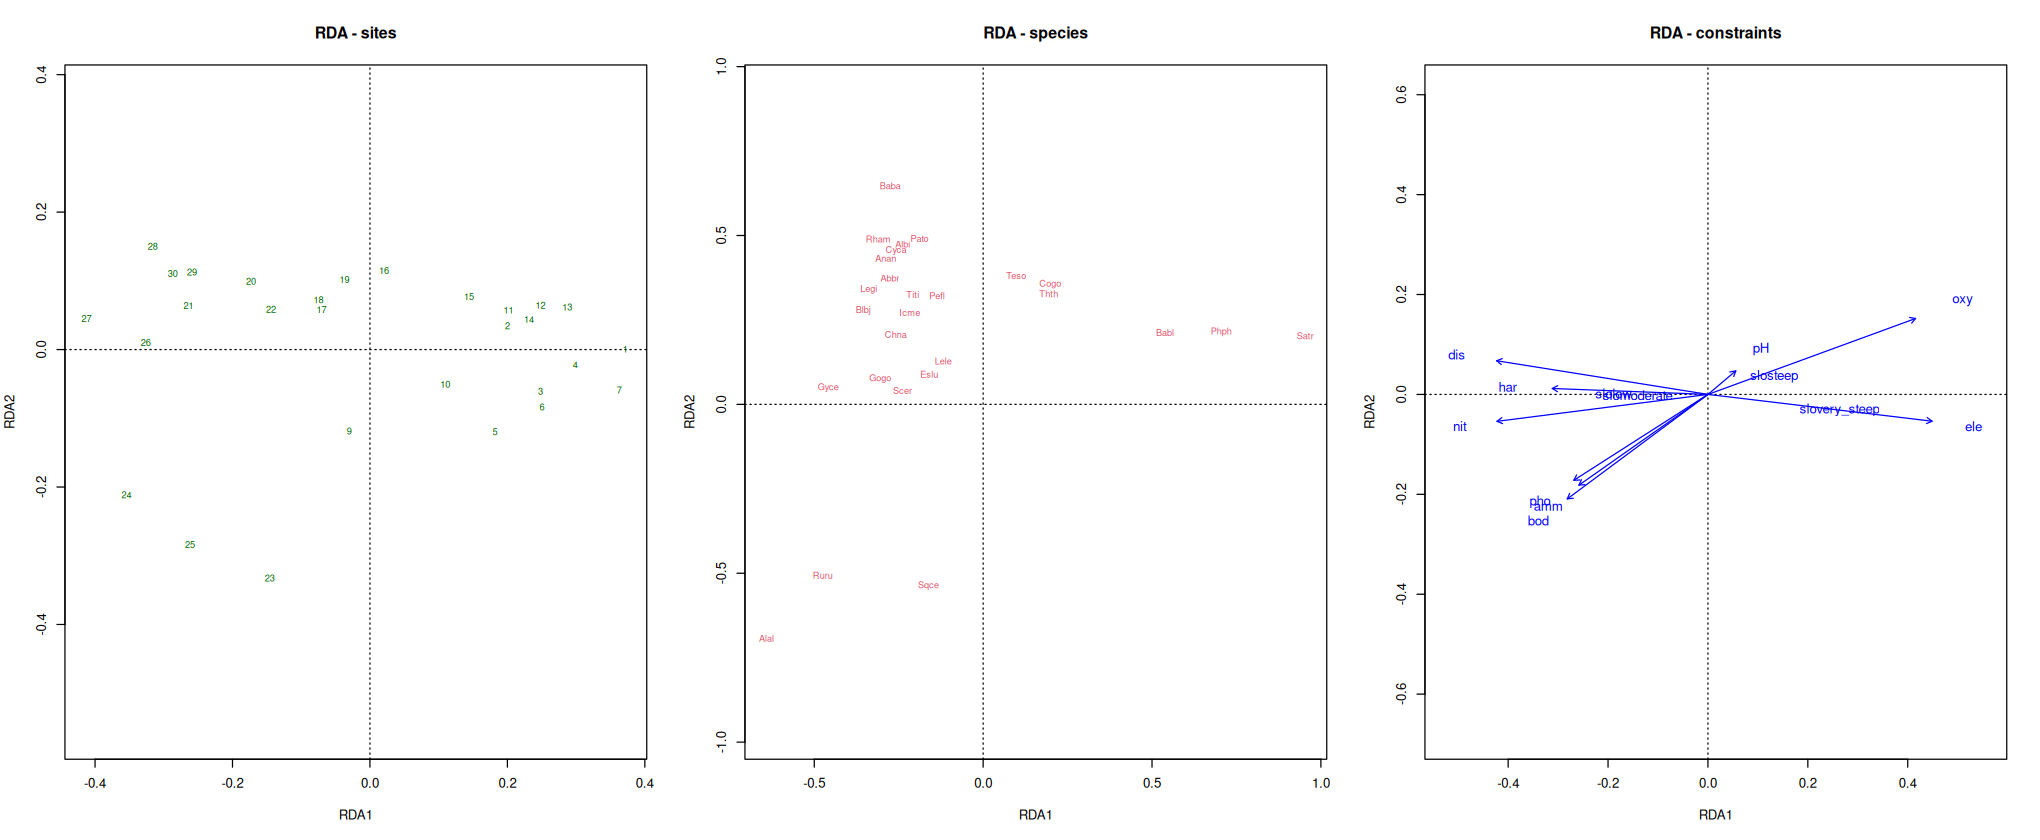

In [13]:
# Set plot size in Jupyter Notebook (17 x 7 inches)
options(repr.plot.width = 17, repr.plot.height = 7)

## Triplots of the rda results (lc site scores)
## Site scores as linear combinations of the environmental variables
par(mfrow=c(1,3))
plot(spe.rda, scaling = 1,   display = c("lc"), main = "RDA - sites")
plot(spe.rda, scaling = 1,   display = c("sp"), main = "RDA - species")
plot(spe.rda, scaling = 1,   display = c("cn"), main = "RDA - constraints")

## 2.5 Displaying RDA plot with sites, species and constraints on the same triplot

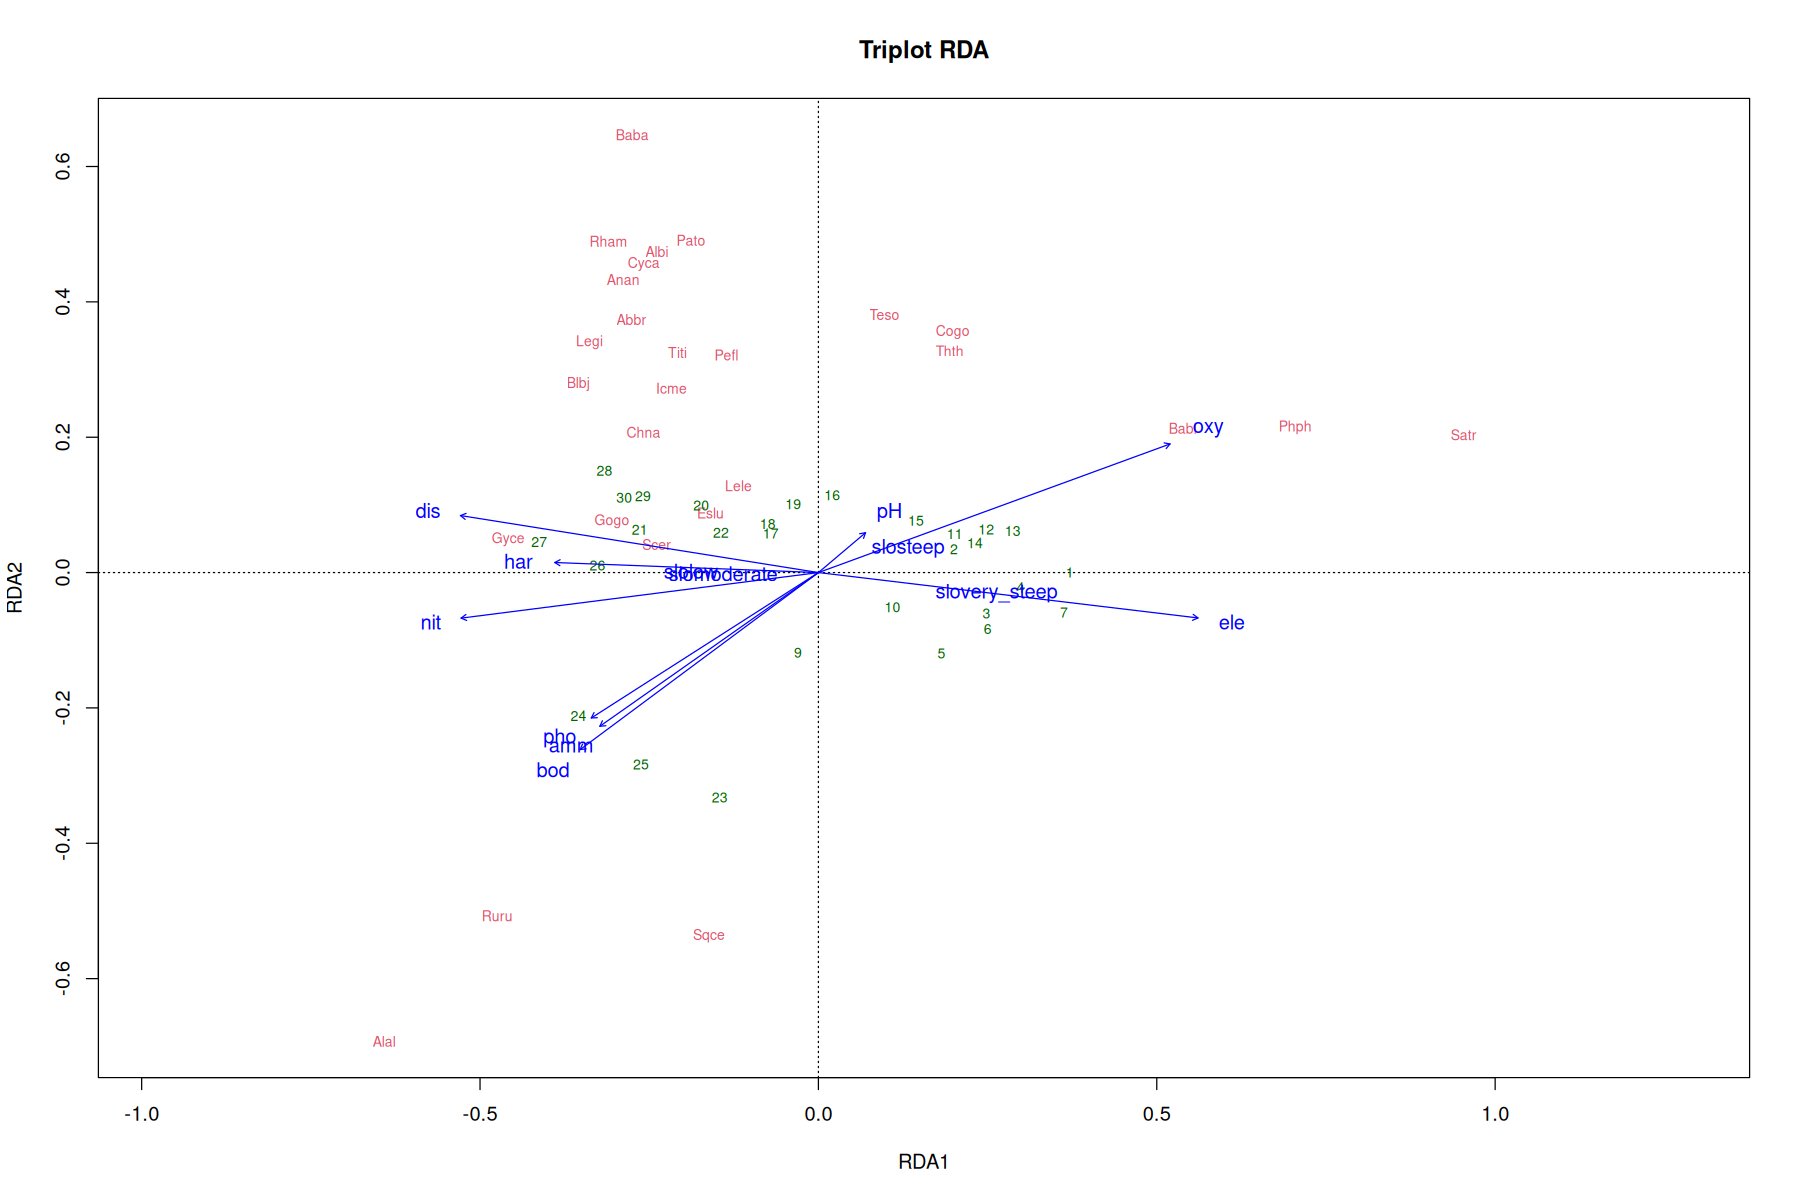

In [14]:
# Set plot size in Jupyter Notebook (17 x 12 inches)
options(repr.plot.width = 15, repr.plot.height = 10)

par(mfrow=c(1,1))

# Plot the RDA result as a triplot
# Display site scores ("lc"), species scores ("sp"), and constraints ("cn")
plot(spe.rda, scaling=1, disp=c("lc","sp","cn"), main="Triplot RDA")

### 2.0.5 Assess Sample-wise Fit Quality -> **goodness**( *ordination_object* )

- **`ordination_object`** → *Ordination object computed using `rda()`*

- **goodness output** :


- **`Goodness values`** : One value per sample, representing the **distance between the original and ordinated configuration** for that sample  
- **`Interpretation`** :  
   - **Low values** = good fit (the sample is well-represented in the NMDS space)  
   - **High values** = poor fit (the sample's position in reduced space is less accurate)  


## 2.6 Select species with goodness-of-fit of at least 0.6 in the ordination plane formed by axes 1 and 2

In [15]:
# Calculate the goodness-of-fit values for species in the RDA object
spe.good <- goodness(spe.rda)

spe.good

# Select species with goodness-of-fit (second column : RDA2) greater or equal to 0.6
sel.sp <- which(spe.good[, 2] >= 0.6)

print(sel.sp)


,RDA1,RDA2,RDA3,RDA4,RDA5,RDA6,RDA7,RDA8,RDA9,RDA10,RDA11,RDA12
Cogo,0.15023204,0.26342116,0.73918776,0.74206701,0.75768717,0.7650975,0.7658098,0.7658727,0.7694676,0.7703921,0.7776257,0.7792702
Satr,0.77317189,0.78146691,0.81011222,0.87190399,0.87207610,0.8737382,0.8748587,0.8748986,0.8749805,0.8770450,0.8781003,0.8781251
Phph,0.63312928,0.64692771,0.64721724,0.68458957,0.69035666,0.6928903,0.6971255,0.6996012,0.6997714,0.7015839,0.7027491,0.7027504
Babl,0.49168092,0.50982709,0.51620905,0.65200779,0.66024870,0.6604041,0.6604569,0.6653997,0.6654898,0.6655837,0.6657961,0.6657982
Thth,0.13546280,0.22621792,0.67942470,0.69441189,0.72870423,0.7287994,0.7336195,0.7451159,0.7455856,0.7493727,0.7506190,0.7506548
Teso,0.03819181,0.17496294,0.58876459,0.58892180,0.59307509,0.5932299,0.6075924,0.6263386,0.6293789,0.6298110,0.6326389,0.6347487
Chna,0.52670964,0.60638932,0.60761382,0.61228541,0.72276526,0.7574617,0.7644692,0.7646013,0.7779609,0.7817214,0.7819355,0.7823743
Pato,0.18351099,0.47759255,0.49213602,0.49508050,0.58680869,0.5868501,0.6115110,0.6377409,0.6377409,0.6448473,0.6459433,0.6471556
Lele,0.04898499,0.06261979,0.06307531,0.09012532,0.09880679,0.2128267,0.2129790,0.2166504,0.2239820,0.2256727,0.2319910,0.2338860
Sqce,0.08965503,0.32207568,0.38317903,0.59699961,0.59984279,0.6004206,0.6334265,0.6390870,0.6612524,0.6643533,0.6681391,0.6681881


Satr Phph Chna Baba Albi Rham Legi Cyca Abbr Gyce Ruru Blbj Alal Anan 
   2    3    7   11   12   16   17   19   21   23   24   25   26   27 


<div style="padding: 10px; border:1px solid red; font-size: 18px; position: relative;">
  <span style="text-decoration:underline; font-weight: bold; font-size: 22px;">Question 5</span><br/>

  <div style="display: flex; align-items: flex-start;">
    <div style="flex: 1;">
        Here is a triplot of an RDA on 30 sites (1-30) where the explanatory variables are the oxgen concentration (oxy), the altitude (alt) and Biochemical Oxygen Demand (dbo). In red we can see the species, in black the sites and in blue vectors the mentionned explanatory variables. <br/><br/><br/><br/>
        <strong>Which statements are correct? </strong>
    </div>
    <div style="margin-left: 20px;">
      <img src="images/Script6_Q5.png" alt="Skewed distribution" style="max-width: 1000px; height: auto; border: 1px solid #ccc;" />
    </div>
  </div>

<form>
  <label><input type="radio" name="q5" value="1"> 1) Sites 2 and 12 are really similar</label><br/>
  <label><input type="radio" name="q5" value="2"> 2) Sites 7 and 8 are quite similar and have both high pH</label><br/>
  <label><input type="radio" name="q5" value="3"> 3) Site 5 has a really high temperature</label><br/>
  <label><input type="radio" name="q5" value="4"> 4) Site 1 is the site characterised by the highest humidity</label><br/>
  <label><input type="radio" name="q5" value="5"> 5) Temperature contributes the most explaining differences among the 12 soil type</label><br/>
</form>

</div>

<details style="font-size: 18px;">
  <summary style="font-size: 20px; font-weight: bold; text-decoration: underline;">Answer</summary>
  <div style="padding: 10px; border:1px solid blue; font-size: 20px;">


<form>
  <label><input type="radio" name="q5" value="1"> 1) Sites 2 and 12 are really similar</label><br/>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring"> 2) Sites 7 and 8 are quite similar and have both high pH</label><br/>
  <label><input type="radio" name="q5" value="3"> 3) Site 5 has a really high temperature</label><br/>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring"> 4) Site 1 is the site characterised by the highest humidity</label><br/>
  <label style="color: blue;"><input type="radio" name="q5" value="squaring"> 5) Temperature contributes the most explaining differences among the 12 soil type</label><br/>
</form>


  </div>
</details>


# 3 Anova -> *anova*()


*Permutation Test for Constrained Correspondence Analysis*

<div style="padding: 10px; border:5px solid green; font-size: 13px; text-align: left;">
    
> Perform a permutation test to calculate the variance explained by the model (i.e., the explanatory variables used in the ordination) and assess whether it is statistically significant (p-value < 0.005).
    <img src="images/Script6_ANOVA.png" width="55%">
</div>


### 3.0.1 Global ANOVA on a supervised ordination object -> ***anova**(ordination_object, permutations = how(nperm = `n`))*

*RDA computation* 

- **`ordination_object`** → *Supervised ordination object resulted from rda() or cca()*
- **`n`** → *number of permutations for the ANOVA (generally 999)*
- 
**outputs :**

- **Df** :

  - `"Model"`: Degrees of freedom used by the explanatory variables (can be more than the number of variables if some are factors with multiple levels). 
  - `"Residual"`: Remaining degrees of freedom (number of objects - model Df - 1).
    
- **Variance** :
  - `"Model"` : Variance explained by the model
  - `"Residual"`: Variance left unexplained

- **F** :
  - `"Model"` : F-statistic = ratio of explained variance to unexplained variance
  - `"Residual"`: NA

- **Pr(>F)** :
  - `"Model"` :  P-value (< 0.05 or 0.01) means the model is statistically significant.
  - `"Residual"`: NA


## 3.1 Global ANOVA test of the RDA on `spe` using the explanatory variables from `env3`

In [16]:
# Global test of the RDA result
anova(spe.rda, permutations = how(nperm = 999))

,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,12,0.3653713,3.552322,0.001
Residual,16,0.1371389,NA,NA


### 3.0.2 ANOVA on canonical axes of a  supervised ordination object -> ***anova**(ordination_object, by = "axis", permutations = how(nperm = `n`))*

*RDA computation* 

- **`ordination_object`** → *Supervised ordination object resulted from rda() or cca()*
- **`n`** → *number of permutations for the ANOVA (generally 999)*
- 
**outputs :**

- **Df** :

  - `"RDA1"`: As each canonical axis corresponds to 1 degree of freedom -> 1 
  - `"RDAn"`: As each canonical axis corresponds to 1 degree of freedom -> 1  
    
- **Variance** :
  - `"RDA1"` : Variance explained by individual canonical axis
  - `"RDAn"`: Variance explained by individual canonical  axis

- **F** :
  - `"RDA1"` : F-statistic for each axis, calculated as the ratio of variance explained by that axis to the unexplained variance.
  - `"RDAn"`: F-statistic for each axis, calculated as the ratio of variance explained by that axis to the unexplained variance.

- **Pr(>F)** :
  - `"RDA1"` :  P-value from the permutation test for each axis. < 0.05 (or 0.01) indicates that the axis explains a statistically significant portion of the variance.
  - `"RDAn"`: P-value from the permutation test for each axis. < 0.05 (or 0.01) indicates that the axis explains a statistically significant portion of the variance.


## 3.2 ANOVA test of the RDA on `spe` using the explanatory variables from `env3` on all canonical axis

In [17]:
# Tests of all canonical axes
anova(spe.rda, by = "axis", permutations = how(nperm = 999))

,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,0.2280834722,26.61049745,0.001
RDA2,1,0.0536975446,6.65644800,0.005
RDA3,1,0.0321191985,4.21576505,0.172
RDA4,1,0.0232058258,3.21506549,0.540
RDA5,1,0.0086988628,1.26862034,1.000
RDA6,1,0.0072177405,0.84209374,NA
RDA7,1,0.0048689264,0.56805761,NA
RDA8,1,0.0029241643,0.34116223,NA
RDA9,1,0.0021410130,0.24979198,NA


<div style="padding: 10px; border:1px solid red; font-size: 18px; position: relative;">
  <span style="text-decoration:underline; font-weight: bold; font-size: 22px;">Question 6</span><br/>

  <div style="display: flex; align-items: flex-start;">
    <div style="flex: 1;">
       Here is a table resulting from an ANOVA test on an RDA object<br/><br/><br/><br/>
        <strong>Which statements are correct? </strong>
    </div>
    <div style="margin-left: 20px;">
      <img src="images/Script6_QuestionAnova.png" alt="RDA ANOVA" style="max-width: 1000px; height: auto; border: 1px solid #ccc;" />
    </div>
  </div>

<form>
  <label><input type="radio" name="q6" value="1"> 1) RDA1 explains a significant part of the variance</label><br/>
  <label><input type="radio" name="q6" value="2"> 2) RDA2 is also significant and explains more variance than RDA1</label><br/>
  <label><input type="radio" name="q6" value="3"> 3) RDA3 does not significantly explain variance</label><br/>
  <label><input type="radio" name="q6" value="4"> 4) Residuals account for more variance than all constrained axes combined</label><br/>
  <label><input type="radio" name="q6" value="5"> 5) RDA3 is significant</label><br/>
</form>
</div>


<details style="font-size: 18px;">
  <summary style="font-size: 20px; font-weight: bold; text-decoration: underline;">Answer</summary>
  <div style="padding: 10px; border:1px solid blue; font-size: 20px;">

<form>
  <label style="color: blue;"><input type="radio" name="q6" value="1"> 1) RDA1 explains a significant part of the variance ✅ (True)</label><br/>
  <label><input type="radio" name="q6" value="2"> 2) RDA2 is also significant and explains more variance than RDA1 ❌ (False)</label><br/>
  <label style="color: blue;"><input type="radio" name="q6" value="3"> 3) RDA3 does not significantly explain variance ✅ (True)</label><br/>
  <label style="color: blue;"><input type="radio" name="q6" value="4"> 4) Residuals account for more variance than all constrained axes combined ✅ (True)</label><br/>
  <label><input type="radio" name="q6" value="5"> 5) RDA3 is significant ❌ (False)</label><br/>
</form>

  </div>
</details>


# 4 VIF (Variance Inflation Factor) -> *vif.cca()*

<div style="padding: 10px; border:5px solid green; font-size: 19px; text-align: left;">
    
> Calculate the Variance Inflation Factor (VIF) for each explanatory variable to detect multicollinearity. Variables with VIF > 10 may indicate problematic collinearity. <br><br><br>
    <img src="images/Script6_VIF.png" width="45%">
</div>


### 4.0.1 VIF (Variance Inflation Factor)  of a  supervised ordination object -> ***vif.cca**(ordination_object)*

*VIF computation* 

- **`ordination_object`** → *Supervised ordination object resulted from rda() or cca()*

  
**outputs :**

- **variable** : VIF value 


# 4.1 VIF of the RDA for the `spe` dataset with the `env3` variables

In [18]:
# Variance inflation factors (VIF) for each explanatory variables of the RDA
vif.cca(spe.rda)

ele   slomoderate      slosteep slovery_steep           dis 
    20.388897      2.086010      2.988552      4.590576      6.688050 
           pH           har           pho           nit           amm 
     1.363315      3.048720     30.609511     18.947597     40.144136 
          oxy           bod 
     6.848962     17.980015

<div style="padding: 10px; border:1px solid red; font-size: 18px; position: relative;">
  <span style="text-decoration:underline; font-weight: bold; font-size: 22px;">Question 7</span><br/>

  <div style="display: flex; align-items: flex-start;">
    <div style="flex: 1;">
       Here is a table of Variance Inflation Factors (VIF) for explanatory variables<br/><br/><br/><br/>
        <strong>Which statements are correct? </strong>
    </div>
    <div style="margin-left: 20px;">
      <img src="images/Script6_QuestionVIF.png" alt="VIF table" style="max-width: 1000px; height: auto; border: 1px solid #ccc;" />
    </div>
  </div>

<form>
  <label><input type="radio" name="q7" value="1"> 1) Conductivity shows strong collinearity and should be removed</label><br/>
  <label><input type="radio" name="q7" value="2"> 2) Phosphate also shows high collinearity</label><br/>
  <label><input type="radio" name="q7" value="3"> 3) pH has an acceptable VIF value</label><br/>
  <label><input type="radio" name="q7" value="4"> 4) Temperature must be removed from the model</label><br/>
  <label><input type="radio" name="q7" value="5"> 5) Only Nitrate and Dissolved Oxygen can safely stay in the model</label><br/>
</form>
</div>


<details style="font-size: 18px;">
  <summary style="font-size: 20px; font-weight: bold; text-decoration: underline;">Answer</summary>
  <div style="padding: 10px; border:1px solid blue; font-size: 20px;">

<form>
  <label style="color: blue;"><input type="radio" name="q7" value="1"> 1) Conductivity shows strong collinearity and should be removed ✅ (True)</label><br/>
  <label style="color: blue;"><input type="radio" name="q7" value="2"> 2) Phosphate also shows high collinearity ✅ (True)</label><br/>
  <label style="color: blue;"><input type="radio" name="q7" value="3"> 3) pH has an acceptable VIF value ✅ (True)</label><br/>
  <label><input type="radio" name="q7" value="4"> 4) Temperature must be removed from the model ❌ (False)</label><br/>
  <label><input type="radio" name="q7" value="5"> 5) Only Nitrate and Dissolved Oxygen can safely stay in the model ❌ (False)</label><br/>
</form>

  </div>
</details>


# 5 Partial Redundancy analysis (PRDA) -> *rda()*

> The **partial RDA** is a method used to **assess** how much a set of **explanatory variables** **explains** the variation in **species data**, while **controlling for** the effect of other variables. It **quantifies** the **pure effect** of the variables of interest by **removing** the influence of the **conditioning variables**.

### 5.0.1 Partial RDA computation based on a dataframe and explanatory variables -> :

***rda**( df ~ df_env_interest, df_env_removed,scale = `TRUE/FALSE`)*

***rda**(df ~ var1 + var2 + ... + varn + Condition(var_contr1 + .. + var_contrn), data = df_env)*



*Partial RDA computation* 

- **`df`** → *Dataframe with the objects (freqeuncy table)*
- **`df_env_interest`** → *Dataframe with the explanatory variables of interest*  
- **`~ df_env_removed`** → *Selected environmental variables used as explanatory variables in the model*
- **`var1 +..+ varn`** → *variables to  isolate*
- **`var_contr1 +...+ var_contrn`** → *variable to control*  
- **`~ df_env`** → *Dataframe with the explanatory variables (environnemntal parameters)*  
- **`TRUE/FALSE`** → *Argument scale*:  
  - `"TRUE"`:  variables are standardized 
  - `"FALSE"`: variables are not standardized
 
**outputs** : 

- **Inertia (explained variance)** :

  - `"Total"`: Total variance explained by all variables 
  - `"Unconstrained"`: Total variance explained, when the ordination is an unconstrained analysis
  - `"Constrained"`: Total variance explained, when the ordination is an constrained analysis
  - `"Conditionned"`: Variance explained by the variables that are “controlled”

    
- **Proportion** :
  - `"Total"` : proportion total explained (1)
  - `"Unconstrained"`: porportion of the variance explained when the ordinatio is nan unconstrained analysis
  - `"Constrained"`:  porportion of the variance explained when the ordination is an constrained analysis
  - `"Conditionned"`:  porportion of the Variance explained by the variables that are “controlled”

## 5.1 Comparing Normal and Partial RDA: Isolating the Effect of Water Chemistry

In [19]:
## "normal" Constrained RDA: effect of water chemistry
spe.chem.rda <- rda(spe.hel, envchem) # Analyzes the total effect of water chemistry on species.
summary(spe.chem.rda) 

## Partial RDA: effect of water chemistry, holding topography constant (=factoring out topography)
spe.chem.physio.rda<-rda(spe.hel, envchem, envtopo) # Analyzes the pure effect of chemistry by removing the effect of topography (elevation, slope, distance).
summary(spe.chem.physio.rda)

# Partial RDA: effect of water chemistry, holding topography constant (=factoring out topography)
spe.chem.physio.rda.2 <- rda(spe.hel ~ pH + har + pho + nit + amm + oxy + bod + Condition(ele + slo + dis), data = env2)  # Analyzes the pure effect of chemistry by removing the effect of topography (elevation, slope, distance).
summary(spe.chem.physio.rda.2)


Call:
rda(X = spe.hel, Y = envchem) 

Partitioning of variance:
              Inertia Proportion
Total          0.5025     1.0000
Constrained    0.3044     0.6058
Unconstrained  0.1981     0.3942

Eigenvalues, and their contribution to the variance 

Importance of components:
                        RDA1    RDA2    RDA3     RDA4     RDA5     RDA6
Eigenvalue            0.2068 0.05017 0.02728 0.009591 0.004963 0.004084
Proportion Explained  0.4116 0.09984 0.05429 0.019086 0.009877 0.008127
Cumulative Proportion 0.4116 0.51145 0.56574 0.584824 0.594702 0.602829
                          RDA7     PC1     PC2     PC3     PC4     PC5     PC6
Eigenvalue            0.001488 0.06215 0.04072 0.02078 0.01675 0.01437 0.01211
Proportion Explained  0.002962 0.12368 0.08104 0.04135 0.03333 0.02859 0.02409
Cumulative Proportion 0.605791 0.72947 0.81051 0.85186 0.88520 0.91379 0.93788
                          PC7      PC8      PC9     PC10     PC11     PC12
Eigenvalue            0.00866 0.005845 0.00


Call:
rda(X = spe.hel, Y = envchem, Z = envtopo) 

Partitioning of variance:
              Inertia Proportion
Total          0.5025     1.0000
Conditioned    0.2087     0.4152
Constrained    0.1602     0.3189
Unconstrained  0.1336     0.2659

Eigenvalues, and their contribution to the variance 
after removing the contribution of conditiniong variables

Importance of components:
                         RDA1   RDA2     RDA3    RDA4     RDA5     RDA6
Eigenvalue            0.09136 0.0459 0.009277 0.00625 0.003868 0.002145
Proportion Explained  0.31092 0.1562 0.031570 0.02127 0.013163 0.007300
Cumulative Proportion 0.31092 0.4671 0.498706 0.51998 0.533139 0.540439
                          RDA7     PC1     PC2     PC3     PC4      PC5
Eigenvalue            0.001424 0.04643 0.02071 0.01746 0.01326 0.009747
Proportion Explained  0.004848 0.15801 0.07049 0.05942 0.04511 0.033170
Cumulative Proportion 0.545286 0.70329 0.77378 0.83320 0.87831 0.911480
                           PC6      PC7   


Call:
rda(formula = spe.hel ~ pH + har + pho + nit + amm + oxy + bod +      Condition(ele + slo + dis), data = env2) 

Partitioning of variance:
              Inertia Proportion
Total          0.5025     1.0000
Conditioned    0.2087     0.4152
Constrained    0.1602     0.3189
Unconstrained  0.1336     0.2659

Eigenvalues, and their contribution to the variance 
after removing the contribution of conditiniong variables

Importance of components:
                         RDA1   RDA2     RDA3    RDA4     RDA5     RDA6
Eigenvalue            0.09136 0.0459 0.009277 0.00625 0.003868 0.002145
Proportion Explained  0.31092 0.1562 0.031570 0.02127 0.013163 0.007300
Cumulative Proportion 0.31092 0.4671 0.498706 0.51998 0.533139 0.540439
                          RDA7     PC1     PC2     PC3     PC4      PC5
Eigenvalue            0.001424 0.04643 0.02071 0.01746 0.01326 0.009747
Proportion Explained  0.004848 0.15801 0.07049 0.05942 0.04511 0.033170
Cumulative Proportion 0.545286 0.70329 0.77378

## 5.2 Comparing plots of Normal and Partial RDA: Isolating the Effect of Water Chemistry

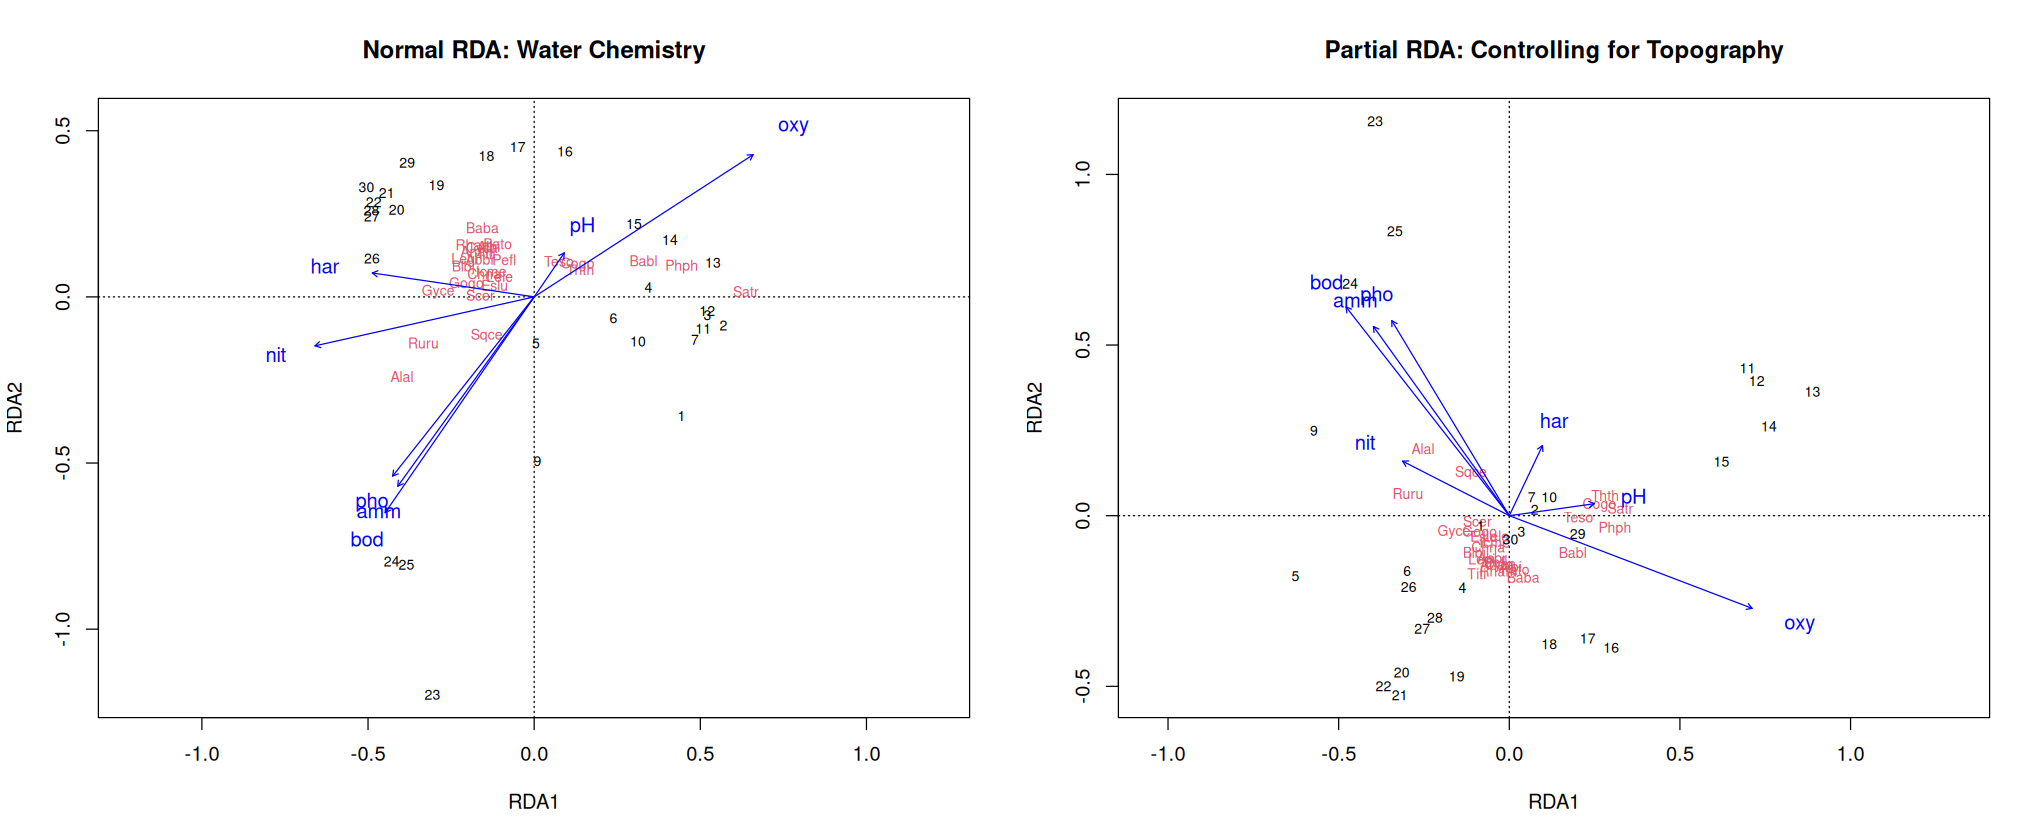

In [20]:
# Set plot size in Jupyter Notebook (17 x 7 inches)
options(repr.plot.width = 17, repr.plot.height = 7)

## Plot Normal RDA and Partial RDA side by side
par(mfrow = c(1, 2)) 

## "Normal" Constrained RDA: effect of water chemistry
plot(spe.chem.rda, main = "Normal RDA: Water Chemistry")  

## Partial RDA: effect of water chemistry while holding topography constant
plot(spe.chem.physio.rda, main = "Partial RDA: Controlling for Topography")  

## 5.3 ANOVA of the partial RDA Model and Its Canonical Axes

In [21]:
# Global test of the partial RDA model significance
anova(spe.chem.physio.rda.2, permutations = how(nperm = 999))

# Test of the significance of each partial RDA axis
anova(spe.chem.physio.rda.2, permutations = how(nperm = 999), by = "axis")

,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,7,0.1602319,3.083622,0.001
Residual,18,0.1336171,NA,NA


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,0.091363167,12.3078295,0.001
RDA2,1,0.045904268,6.5274640,0.002
RDA3,1,0.009276688,1.3885476,0.933
RDA4,1,0.006250462,0.9823567,0.985
RDA5,1,0.003867825,0.6368356,0.992
RDA6,1,0.002144963,0.3692203,0.998
RDA7,1,0.001424497,0.2558649,0.998
Residual,18,0.133617142,NA,NA


## 5.4 VIF Analysis of the Partial RDA Model

In [22]:
# VIF of Partial RDA 
vif.cca(spe.chem.physio.rda.2)

ele       slo       dis        pH       har       pho       nit       amm 
16.181925  1.873589  6.712254  1.205159  3.268186 25.354012 16.066450 30.696239 
      oxy       bod 
 6.900477 17.781124

# 6 selection of variables -> *ordistep*()

### 6.0.1 Forward and Backward selction of explanatory variables -> ordistep(*`ordination_object`, `scope =`,`direction = ` , permutations = how(nperm = `n`*)

*Stepwise search for explainatory variables* 

- **`ordination_object`** → *Ordination object resulting from cca() or rda()*
- **`scope = `** → *Set of candidate explanatory variables from which the model will select.*  
- **`direction = `** → *mode of stepwise search*
  - `"forward"`: Start with empty model, add variables one by one until no remaining variable significantly improves the explanation of the variance. 
  - `"backward"/" "`: Start with complete model (all scope variables) and remove variables one by one until all the remaining variables are significant.
  - `"both"`: Combination of both methods: variables can be added or removed at each stage.
- **`n`** → *number of permutations*
  
**outputs** : 

Step : `df ~ Variable1 + Variable2 +... + Variablen` -> Indicates the current model tested at this stage.

- **DF** : *Number of degrees of freedom added or tested by the candidate variable (often 1 here because only one variable is added).*
- **AIC** : *Measurement of model quality, lower the value, the better the model.*
- **F** : *Statistic F of the variable addition test*
- **Pr(>F)** : *p-value associated with the F-test*



## 6.1 Forward Selection in RDA for the `spe` Dataset

In [23]:
# Create an RDA model including all explanatory variables from env2, except 'dfs'
spe.rda.all <- rda(spe.hel ~ ., data = env2)

# Define the initial empty model (unconstrained RDA, with no explanatory variables)
mod0 <- rda(spe.hel ~ 1, data = env2)

# Perform forward stepwise selection by adding variables one at a time from those in spe.rda.all
step.forward <- ordistep(mod0, scope = formula(spe.rda.all), 
                         direction = "forward", permutations = how(nperm = 999))
step.forward

 # Adjusted R-squared for the selected model from forward selection method  
RsquareAdj(step.forward)


Start: spe.hel ~ 1 

      Df     AIC       F Pr(>F)    
+ ele  1 -28.504 13.1828  0.001 ***
+ oxy  1 -27.420 11.7086  0.001 ***
+ dis  1 -26.872 10.9840  0.001 ***
+ nit  1 -26.716 10.7795  0.001 ***
+ bod  1 -23.172  6.4340  0.001 ***
+ har  1 -22.499  5.6673  0.001 ***
+ pho  1 -22.189  5.3200  0.001 ***
+ amm  1 -22.047  5.1620  0.001 ***
+ slo  1 -20.155  3.1305  0.001 ***
+ pH   1 -17.489  0.4839  0.787    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Step: spe.hel ~ ele 

      Df     AIC      F Pr(>F)    
+ oxy  1 -34.617 8.3932  0.001 ***
+ bod  1 -32.102 5.5357  0.001 ***
+ amm  1 -30.777 4.1270  0.003 ** 
+ pho  1 -30.559 3.9019  0.004 ** 
+ slo  1 -29.049 2.3850  0.021 *  
+ nit  1 -29.449 2.7790  0.025 *  
+ dis  1 -27.971 1.3490  0.225    
+ har  1 -27.955 1.3335  0.256    
+ pH   1 -27.427 0.8406  0.451    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Step: spe.hel ~ ele + oxy 

      Df     AIC      F Pr(>F)    
+ slo  1 -3


Call: rda(formula = spe.hel ~ ele + oxy + slo + bod, data = env2)

              Inertia Proportion Rank
Total          0.5025     1.0000     
Constrained    0.3279     0.6526    4
Unconstrained  0.1746     0.3474   24

Inertia is variance

Eigenvalues for constrained axes:
   RDA1    RDA2    RDA3    RDA4 
0.22274 0.05172 0.02903 0.02445 

Eigenvalues for unconstrained axes:
    PC1     PC2     PC3     PC4     PC5     PC6     PC7     PC8 
0.05194 0.02965 0.02568 0.01527 0.01368 0.00790 0.00656 0.00540 
(Showing 8 of 24 unconstrained eigenvalues)


$r.squared
[1] 0.6526117

$adj.r.squared
[1] 0.5947137

## 6.2 Backward Selection in RDA for the `spe` Dataset

In [24]:
# Perform backward stepwise selection starting from the full RDA model (spe.rda.all)
# Note: when 'direction' is not specified, ordistep() defaults to backward selection
step.backward <- ordistep(spe.rda.all, permutations = how(nperm = 999))

RsquareAdj(step.backward)


Start: spe.hel ~ ele + slo + dis + pH + har + pho + nit + amm + oxy +      bod 

      Df     AIC      F Pr(>F)   
- nit  1 -38.524 0.5442  0.755   
- amm  1 -38.483 0.5708  0.687   
- pH   1 -38.416 0.6135  0.667   
- bod  1 -38.361 0.6492  0.614   
- pho  1 -38.102 0.8160  0.500   
- har  1 -37.121 1.4639  0.225   
- dis  1 -37.218 1.3989  0.201   
- ele  1 -36.819 1.6677  0.157   
- slo  1 -35.038 2.9129  0.031 * 
- oxy  1 -32.918 4.4990  0.005 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Step: spe.hel ~ ele + slo + dis + pH + har + pho + amm + oxy + bod 

      Df     AIC      F Pr(>F)    
- pH   1 -39.643 0.5863  0.698    
- amm  1 -39.581 0.6285  0.639    
- pho  1 -39.259 0.8475  0.454    
- dis  1 -38.464 1.3993  0.214    
- har  1 -38.204 1.5825  0.178    
- bod  1 -37.532 2.0651  0.079 .  
- slo  1 -36.287 2.9891  0.015 *  
- ele  1 -34.306 4.5440  0.008 ** 
- oxy  1 -30.645 7.7122  0.001 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 

$r.squared
[1] 0.6526117

$adj.r.squared
[1] 0.5947137

## 6.3 Forward selection in Partial RDA for the `spe` Dataset

### 6.0.2 Forward selection based on adjusted R² and permutation tests -> ordiR2step(*`ordination_object`, `scope =`,`direction = ` , permutations = how(nperm = `n`*)

*Forward selection for explanatory variables based on adjusted R² and permutation tests.* 

- **`ordination_object`** → *Ordination object resulting from rda() or capscale()*
- **`scope = `** → *Set of candidate explanatory variables from which the model will select.*  
- **`direction = `** → *mode of stepwise search*
  - Only "`forward`" possible. 
  - Starts with an empty model (or one containing only the covariates specified with Condition()).
  - Each variable added must:
    - Be significant in the permutation test.
    - Increase the adjusted R² of the model.
    
- **`n`** → *number of permutations*
  
**outputs** : 

Step : `R2.adj= ` -> Shows the adjusted R² of the model at this step (after adding the variable). When shown for each candidate variable, it represents the adjusted R² that would result if that variable were added to the current model.
Call : Shows the model tested

- **DF** : *Number of degrees of freedom added or tested by the candidate variable (often 1 here because only one variable is added).*
- **AIC** : *Measurement of model quality, lower the value, the better the model.*
- **F** : *Statistic F of the variable addition test*
- **Pr(>F)** : *p-value associated with the F-test*



## 6.4 Forward selection with ordir2step

In [25]:
# Create a partial RDA model with only 'slo' as a covariate (its effect is controlled for)
mod0p <- rda(spe.hel ~ Condition(slo), data = env2)

# Create a full RDA model with all environmental variables plus 'slo' as a covariate
mod1p <- rda(spe.hel ~ . + Condition(slo), data = env2)

# Perform forward selection starting from mod0p, adding variables from mod1p
# Each selected variable must increase the adjusted R² and be significant (permutation test with 999 permutations)
step.p.forward <- ordiR2step(mod0p, scope = formula(mod1p), direction = "forward", permutations = how(nperm = 999))



Some constraints or conditions were aliased because they were redundant. This
can happen if terms are constant or linearly dependent (collinear): ‘slo’



Step: R2.adj= 0 
Call: spe.hel ~ Condition(slo) 
 
                R2.adjusted
<All variables>  0.51566871
+ ele            0.26647521
+ oxy            0.25175157
+ dis            0.23001777
+ nit            0.22607202
+ bod            0.15475788
+ pho            0.12353536
+ amm            0.12149477
+ har            0.09064060
<model>          0.00000000
+ slo            0.00000000
+ pH            -0.00586061

      Df     AIC      F Pr(>F)    
+ ele  1 -29.049 11.855  0.001 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Step: R2.adj= 0.2664752 
Call: spe.hel ~ Condition(slo) + ele 
 
                R2.adjusted
<All variables>   0.5156687
+ oxy             0.4298908
+ bod             0.3720296
+ amm             0.3430671
+ pho             0.3380145
+ nit             0.3119738
+ dis             0.2743562
+ har             0.2680043
<model>           0.2664752
+ slo             0.2664752
+ pH              0.2658009

      Df     AIC      F Pr(>F)    
+ oxy  1 

# 7 Canonical Correspondence Analysis (CCA)

<div style="padding: 10px; border:5px solid green; font-size: 10px; text-align: left;">
    <img src="images/Script6_CCA_0.png" width="35%" style="margin-right: 90px;">
    <img src="images/Script6_CCA.png" width="35%">
</div>


### 7.0.1 CCA computation based on a dataframe and explanatory variables -> ***cca**( df ~ df_env$\$$col1 + .. df_env$\$$coln, df_env,scale = `TRUE/FALSE`)*

*CCA computation* 

- **`df`** → *Dataframe with the objects (freqeuncy table)*
- **`df_env`** → *Dataframe with the explanatory variables (environnemntal parameters)*  
- **`~ df$col1 + df$col2 + ... + df$coln`** → *Selected environmental variables used as explanatory variables in the model*:  
  - `"~."`:  Takes every colomns to be the explanatory variables  from the `df_env
- **`TRUE/FALSE`** → *Argument scale*:  
  - `"TRUE"`:  variables are standardized 
  - `"FALSE"`: variables are not standardized

**outputs :**

- **Inertia (explained variance)** :

  - `"Total"`: Total variance explained by all variables 
  - `"Unconstrained"`: Total variance explained, when the ordination is an unconstrained analysis
  - `"Constrained"`: Total variance explained, when the ordination is an constrained analysis

    
- **Proportion** :
  - `"Total"` : proportion total explained (1)
  - `"Unconstrained"`: porportion of the variance explained when the ordinatio is nan unconstrained analysis
  - `"Constrained"`:  porportion of the variance explained when the ordination is an constrained analysis

  
- **Inertia is correlations (argument scale = TRUE)** :  inertia is based on correlations (standardized variables)
- **Inertia is variance (argument scale = FALSE)** : inertia is based on variances (covariances) without standardization

- **Eigenvalues for unconstrained axes:** : Each eigenvalue (CA1, CA2, etc.) corresponds to the variance explained by that principal component of the PCA

- **Eigenvalues for constrained axes:** : Each eigenvalue (CCA1, CCA2, etc.) corresponds to the variance explained by that principal component of the RDA

## 7.1 CCA of the `spe` (untransformed) data, constrained by all (`~.`) environmental variables contained in `env3`

In [26]:
# Perform a CCA on the species data constrained by all environmental variables in env3
spe.cca <- cca(spe ~ ., env3)

# Display a summary of the CCA results using default scaling (Scaling 2)
summary(spe.cca)  # Scaling 2 is the default in vegan



Call:
cca(formula = spe ~ ele + slo + dis + pH + har + pho + nit +      amm + oxy + bod, data = env3) 

Partitioning of scaled Chi-square:
              Inertia Proportion
Total          1.1669     1.0000
Constrained    0.8456     0.7246
Unconstrained  0.3214     0.2754

Eigenvalues, and their contribution to the scaled Chi-square 

Importance of components:
                        CCA1   CCA2    CCA3    CCA4    CCA5    CCA6    CCA7
Eigenvalue            0.5252 0.1282 0.06989 0.04364 0.03151 0.01399 0.01167
Proportion Explained  0.4501 0.1098 0.05989 0.03740 0.02700 0.01199 0.01000
Cumulative Proportion 0.4501 0.5599 0.61981 0.65721 0.68421 0.69621 0.70621
                          CCA8     CCA9    CCA10    CCA11    CCA12    CA1
Eigenvalue            0.008510 0.005539 0.003235 0.002713 0.001479 0.1102
Proportion Explained  0.007292 0.004747 0.002772 0.002325 0.001268 0.0944
Cumulative Proportion 0.713504 0.718250 0.721022 0.723347 0.724615 0.8190
                          CA2     CA3 

## 7.2 Adjusted R² of the CCA model

In [27]:
# adjusted R^2
RsquareAdj(spe.cca)

$r.squared
[1] 0.7246148

$adj.r.squared
[1] 0.5211455

## 7.3 CCA Triplots (using lc site scores)

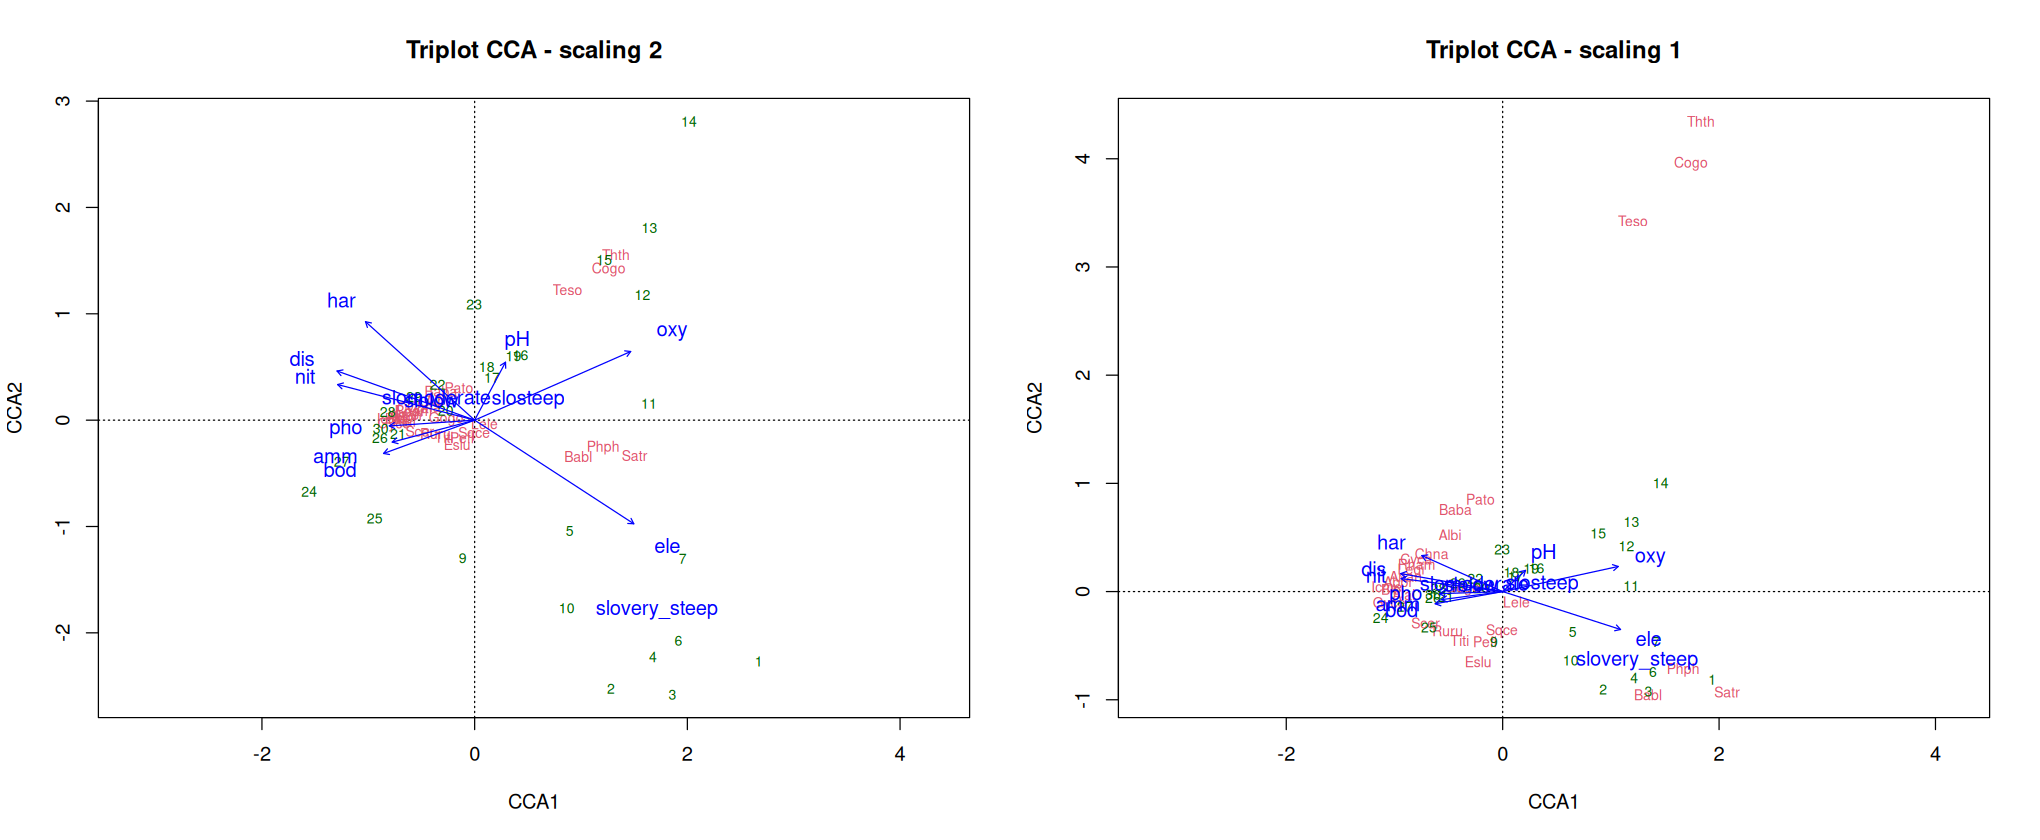

In [28]:
# Set plot size in Jupyter Notebook (17 x 7 inches)
options(repr.plot.width = 17, repr.plot.height = 7)

## CCA triplots (using lc site scores)
par(mfrow = c(1, 2))
# Default scaling 2: site scores scaled to the relative eigenvalues
plot(spe.cca, display = c("sp", "lc", "cn"), main = "Triplot CCA - scaling 2")

# Scaling 1: species scores scaled to the relative eigenvalues
plot(spe.cca,  scaling = 1, display = c("sp", "lc", "cn"), main = "Triplot CCA - scaling 1")

## 7.4 Permutation Tests for CCA

In [29]:
# Permutation test of the overall analysis
anova(spe.cca, permutations = how(nperm = 999))

# Permutation test of each axis
anova(spe.cca, by = "axis", permutations = how(nperm = 999))

,Df,ChiSquare,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,12,0.8455631,3.50837,0.001
Residual,16,0.3213508,NA,NA


,Df,ChiSquare,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
CCA1,1,0.525226556,26.1509374,0.001
CCA2,1,0.128151606,6.3781186,0.003
CCA3,1,0.069889174,4.0544884,0.111
CCA4,1,0.043641123,2.4619497,0.694
CCA5,1,0.031509833,1.7500916,0.895
CCA6,1,0.013994641,0.9466715,1.000
CCA7,1,0.011674819,0.5812872,NA
CCA8,1,0.008509559,0.4236894,NA
CCA9,1,0.005538888,0.2757802,NA


## 7.5 Forward Selection for CCA

In [30]:
## Forward selection for cca
cca.step.forward <- ordistep(cca(spe ~ 1, data = env3), scope = formula(spe.cca), direction = "forward", permutations = how(nperm = 199))


Start: spe ~ 1 

      Df     AIC       F Pr(>F)   
+ ele  1  99.997 12.8211  0.005 **
+ oxy  1 100.885 11.6211  0.005 **
+ dis  1 103.362  8.4593  0.005 **
+ nit  1 103.912  7.7930  0.005 **
+ har  1 105.857  5.5355  0.015 * 
+ slo  3 106.490  2.9447  0.015 * 
+ bod  1 107.219  4.0431  0.025 * 
+ pho  1 107.941  3.2800  0.035 * 
+ amm  1 107.962  3.2577  0.035 * 
+ pH   1 110.469  0.7517  0.480   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Step: spe ~ ele 

      Df     AIC      F Pr(>F)   
+ oxy  1  93.481 8.8751  0.005 **
+ bod  1  98.303 3.5325  0.050 * 
+ amm  1  99.289 2.5455  0.050 * 
+ pho  1  99.883 1.9666  0.105   
+ nit  1 100.320 1.5483  0.205   
+ dis  1 100.269 1.5969  0.225   
+ pH   1 100.858 1.0418  0.335   
+ har  1 101.084 0.8322  0.420   
+ slo  3 103.838 0.6185  0.800   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Step: spe ~ ele + oxy 

      Df    AIC      F Pr(>F)  
+ bod  1 91.268 3.9087  0.015 *
+ pho  1 92.646

## 7.6 Parsimonious CCA using selected variables (ele, oxy, bod)

In [31]:
# Run a CCA using only the selected explanatory variables ele, oxy, and bod
spe.cca.pars <- cca(spe ~ ele + oxy + bod, data = env3)

# Perform a permutation test to see if the overall CCA model is significant
anova(spe.cca.pars, permutations = how(nperm = 999))

# Perform permutation tests for each axis to check which axes significantly explain variance
anova(spe.cca.pars, permutations = how(nperm = 999), by = "axis")

# Compute the adjusted R² to evaluate the proportion of variance explained by this parsimonious model
RsquareAdj(spe.cca.pars)


,Df,ChiSquare,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,3,0.6568106,10.73003,0.001
Residual,25,0.5101033,NA,NA


,Df,ChiSquare,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
CCA1,1,0.50538519,24.768766,0.001
CCA2,1,0.10125474,4.950635,0.001
CCA3,1,0.05017065,2.644246,0.008
Residual,25,0.51010332,NA,NA


$r.squared
[1] 0.5628612

$adj.r.squared
[1] 0.5122239

## 7.7 Variance Inflation Factor (VIF) Check for CCA Models

In [32]:
# Compare variance inflation factors
vif.cca(spe.cca) #initial CCA
vif.cca(spe.cca.pars) #parsimonious CCA

ele   slomoderate      slosteep slovery_steep           dis 
    13.429383      2.356214      2.773088      3.078697      9.616683 
           pH           har           pho           nit           amm 
     1.528714      3.567991     10.982107     11.633352     14.075832 
          oxy           bod 
     6.351786     10.098009

ele      oxy      bod 
1.206933 3.345693 3.002609

# AI Exercises — Script 6: Constrained Ordination

This exercise has four parts: (A) run the same fixed prompt in three AI tools, (B) write and refine your own prompt, (C) cross-check one response with a second AI, and (D) compare and reflect on the tools.

---

## How to provide context to the AI

An AI assistant cannot see this notebook or your live R session unless you explicitly provide that context. Use one of the following methods:

**Option 1 — Attach the notebook (recommended)**
If your AI interface supports file uploads, attach `Script6.ipynb` and ask it to use the notebook as context. The AI still cannot inspect your live R session, so state which cells have been run and paste any relevant error messages or outputs.

**Option 2 — Paste a data snapshot**
If file upload is not available, run the following snippet in R and paste the output at the start of your prompt:

```r
head(spe, 3)
head(env3, 3)
cat("spe.hel dimensions:", dim(spe.hel), "\n")
RsquareAdj(spe.rda)
```

---

## Template prompt (adapt as needed)

> *"I am working with the Doubs dataset in R using the `vegan` package. The dataset has been loaded and site 8 has already been removed, so `spe` has 29 sites and 27 fish species, and `env3` has 29 sites and 11 environmental variables (including a qualitative slope factor). [Attach the notebook or paste the data snapshot here.] [Your specific task here.]"*

> **Important:** Always tell the AI which packages are already loaded (`vegan`) and which objects already exist in your R environment (e.g. `spe`, `env3`, `spe.hel`, `spe.rda`). This prevents unnecessary re-loading or re-computation.

## Part A — Fixed prompt

Copy the prompt below **as-is** into each AI tool. If your interface supports file upload, attach the notebook first.

> *"I am working with the Doubs dataset in R. Site 8 has already been removed, so `spe` has 29 sites and 27 fish species, and `env3` has 29 sites and 11 environmental variables (including a qualitative slope factor). The `vegan` package is loaded, and `spe.hel` is the existing Hellinger-transformed version of `spe`. Using `spe.hel` and `env3`, fit an RDA under a new object name so that the existing `spe.rda` is not overwritten. Produce a scaling-1 triplot containing sites, species and environmental vectors, then run both a global permutation test and an axis-by-axis permutation test. Return runnable R code followed by a concise interpretation."*

---

**If code does not run**, tell the AI:
> *"The code returned the following error: [paste error message]. Please fix it, keeping the same approach."*

---

**Then ask yourself:**
- Did the AI use the existing Hellinger-transformed `spe.hel` object without transforming or filtering the data again?
- Does the triplot show sites, species, and environmental vectors together?
- Did the AI run both a global significance test and an axis-by-axis test?
- In the axis-by-axis ANOVA, which RDA axes are statistically significant (p < 0.05)?

In [ ]:
# Tool 1 — ChatGPT
#
# Key objects available: spe, env3
# Package loaded: vegan

# --- Paste ChatGPT-generated code below this line ---

In [ ]:
# Tool 2 — Claude

# --- Paste Claude-generated code below this line ---

In [ ]:
# Tool 3 — Gemini

# --- Paste Gemini-generated code below this line ---

## Part B — Prompt engineering challenge

Part A used a fixed, detailed prompt. Now write your own prompt to accomplish a more advanced task.

**Your goal:** Ask an AI to perform **stepwise selection of environmental variables** for the RDA and build a parsimonious model containing only the most relevant predictors.

Write the prompt yourself — describe the goal in your own words without specifying the exact functions or arguments to use. Give the AI the necessary context (available objects, loaded packages) and let it decide how to implement the selection.

**After running the AI-generated code, answer the following:**
- Did the AI choose **forward** selection (starting from an empty model), **backward** selection (starting from the full model), or **both**? Does that choice make sense here?
- Does the parsimonious model explain a meaningful proportion of variance? Check the adjusted R².
- Are there any collinearity issues among the selected variables?

Write your prompt in a comment below, paste the AI-generated code, and iterate if needed.

In [ ]:
# My prompt:
# "..."

# --- Paste AI-generated code below this line ---

## Part C — AI-vs-AI Cross-Checking

After generating code with one AI tool (e.g., ChatGPT, Claude) for the prompt engineering part, you pass that output to a **second AI** and ask it to:
- Review the code for errors or inefficiencies
- Suggest cleaner or more idiomatic R solutions
- Flag any ecological/statistical misinterpretations
- Return revised code together with a short change log

Keep both versions, run the revised code in this notebook, and verify its output yourself; do not rely on the second AI's claim that the revision is correct.

## How to evaluate the improvement

Compare the **before** (AI #1 output) and **after** (AI #2 revision) versions across these dimensions:

| Dimension | Before | After |
|---|---|---|
| Lines of code | | |
| Readability (1–5) | | |
| Correctness (any bugs fixed?) | Yes / No | Yes / No |
| Plot quality (1–5) | | |

## Reflection prompts

1. Which two AI tools did you use, and in which order?
2. What was the most significant improvement suggested by the second AI?
3. Did the second AI introduce any new errors or make questionable choices?
4. Would you trust the cross-checked code more than the original? Why or why not?

## Part D — Comparison and evaluation of AI tools

For each AI tool tested in Part A, rate its response on the six criteria below (score out of 5 each, total out of 30).

| Criterion | Description | ChatGPT /5 | Claude /5 | Gemini /5 |
|---|---|---|---|---|
| **Correctness** | Code runs without errors and produces the expected output | | | |
| **Method accuracy** | Applies Hellinger transformation, uses `rda()` correctly, and runs both ANOVA tests | | | |
| **Code clarity** | Code is readable and well structured | | | |
| **Contextual use** | Correctly uses existing objects `spe`, `env3`, `spe.hel`, `spe.rda` without unnecessary redefinition | | | |
| **Interpretation** | Correctly identifies which RDA axes are significant from the axis-by-axis ANOVA and explains what that means | | | |
| **Prompt efficiency** | Minimal back-and-forth needed to get a working result | | | |
| **TOTAL** | | /30 | /30 | /30 |

---

**Focus points for Script 6:**
- Did the AI use the Hellinger-transformed species data before running RDA? Raw community abundances can make Euclidean-based RDA overly influenced by abundant species and joint absences — how does the adjusted R² change with versus without transformation?
- Did the AI produce all three elements in the triplot (sites `"lc"`, species `"sp"`, environmental vectors `"cn"`) and use scaling 1 correctly?
- In Part B, did the forward selection use `ordistep()` with a permutation-based stopping criterion, or `ordiR2step()` with an adjusted R² criterion? Are these equivalent? Which is more conservative?

---

**Reflection question:** Did any AI skip the Hellinger transformation and run RDA directly on raw `spe`? What does that tell you about how well AI tools understand the assumptions of constrained ordination methods?

---

*Suggested tools: [ChatGPT](https://chatgpt.com) · [Claude](https://claude.ai) · [Gemini](https://gemini.google.com)*

## Submission of AI exercise results

Once you have completed Parts A–D, submit the requested Part B results using the form below.

**You will need to provide:**
- The AI tool you used for Part B (ChatGPT, Claude, Gemini, other)
- The prompt you wrote for Part B
- The approximate time spent on the exercise

👉 **[Submit my results](https://forms.gle/2hUKh6LyoWMCJu9F6)**